# Notebook 6: Baseline State and Response Heterogeneity

This notebook asks whether differences in a cell's baseline state can explain its contribution to response heterogeneity.

Predictors are divided into two blocks:

* **Technical:** `ncounts`, `ngenes`, `percent_ribo`
* **Biological state:** the first 10 PCA coordinates

The main question is whether the biological features add explanatory value beyond technical variation. Cells are analyzed together across perturbation groups, using linear regression with bootstrap confidence intervals and permutation testing.


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)

In [2]:
data_path = "F:/scRNA/adamson_pilot_with_response.h5ad"
adata = sc.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 5752 × 14690
    obs: 'perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'response_magnitude'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mean_log_expression', 'variance_log_expression', 'dispersion', 'highly_variable'
    obsm: 'X_pca'
    layers: 'counts'

In [3]:
hvg_mask = adata.var["highly_variable"]
X_hvg = adata[:, hvg_mask].X
X_hvg = np.asarray(X_hvg.todense()) if sp.issparse(X_hvg) else np.asarray(X_hvg)

n_pcs = 10
pca = PCA(n_components=n_pcs, random_state=0)
pcs = pca.fit_transform(X_hvg - X_hvg.mean(axis=0))

Per-cell distance from its own perturbation group's centroid:

In [4]:
categories = adata.obs["perturbation"].cat.categories
deviation = np.zeros(adata.n_obs)

for cat in categories:
    mask = (adata.obs["perturbation"] == cat).values
    centroid = X_hvg[mask].mean(axis=0)
    deviation[mask] = np.linalg.norm(X_hvg[mask] - centroid, axis=1)

adata.obs["within_group_deviation"] = deviation
adata.obs["within_group_deviation"].describe()

count    5752.000000
mean        5.960675
std         1.144079
min         3.436649
25%         5.277645
50%         5.755386
75%         6.369204
max        19.312952
Name: within_group_deviation, dtype: float64

In [5]:
technical_features = adata.obs[["ncounts", "ngenes", "percent_ribo"]].copy()
biological_features = pd.DataFrame(
    pcs[:, :n_pcs], columns=[f"PC{i+1}" for i in range(n_pcs)], index=adata.obs.index
)
all_features = pd.concat([technical_features, biological_features], axis=1)

target = adata.obs["within_group_deviation"].values

Simple pairwise correlations, as a first look before any model fitting:

In [6]:
correlations = all_features.apply(lambda col: np.corrcoef(col, target)[0, 1])
correlations.sort_values(key=abs, ascending=False)

ncounts        -0.655928
ngenes         -0.627152
PC1             0.613053
percent_ribo   -0.344793
PC9            -0.138198
PC3            -0.105532
PC2            -0.043221
PC8             0.024978
PC5             0.023284
PC7            -0.021508
PC10           -0.002378
PC6            -0.002293
PC4             0.000304
dtype: float64

Technical-only model vs. technical + biological state:

In [8]:
def fit_r2(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model, model.score(X, y)

X_technical = technical_features.values
X_full = all_features.values

model_technical, r2_technical = fit_r2(X_technical, target)
model_full, r2_full = fit_r2(X_full, target)

print("R^2, technical features only:", r2_technical)
print("R^2, technical + biological (PCA) features:", r2_full)
print("increment from adding biological state:", r2_full - r2_technical)

R^2, technical features only: 0.4818753369933291
R^2, technical + biological (PCA) features: 0.795118007170668
increment from adding biological state: 0.313242670177339


Bootstrap confidence intervals on the full model's coefficients:

In [9]:
rng = np.random.default_rng(0)
n_boot = 1000
n_cells = X_full.shape[0]

boot_coefs = np.zeros((n_boot, X_full.shape[1]))
for b in range(n_boot):
    idx = rng.integers(0, n_cells, size=n_cells)
    model_b = LinearRegression().fit(X_full[idx], target[idx])
    boot_coefs[b] = model_b.coef_

ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)

coef_table = pd.DataFrame({
    "feature": all_features.columns,
    "coefficient": model_full.coef_,
    "ci_low": ci_low,
    "ci_high": ci_high,
})
coef_table["ci_excludes_zero"] = (coef_table["ci_low"] > 0) | (coef_table["ci_high"] < 0)
coef_table

,feature,coefficient,ci_low,ci_high,ci_excludes_zero
0,ncounts,-0.000063,-0.000093,-0.000035,True
1,ngenes,-0.001076,-0.001288,-0.000861,True
2,percent_ribo,-0.051712,-0.059544,-0.043983,True
3,PC1,0.823306,0.799433,0.845847,True
4,PC2,0.070380,0.035784,0.103112,True
5,PC3,-0.160800,-0.193622,-0.128083,True
6,PC4,-0.084454,-0.120450,-0.046182,True
7,PC5,0.144245,0.110618,0.176875,True
8,PC6,0.035344,-0.006910,0.077064,False
9,PC7,0.204098,0.168300,0.241763,True


Permutation test on the full model's R^2 (breaking any real relationship by shuffling the
target, to see what R^2 this many predictors could reach on pure noise):

In [10]:
rng = np.random.default_rng(1)
n_perm = 1000

null_r2 = np.zeros(n_perm)
for p in range(n_perm):
    shuffled_target = rng.permutation(target)
    _, r2_p = fit_r2(X_full, shuffled_target)
    null_r2[p] = r2_p

p_value = (null_r2 >= r2_full).mean()
print("observed R^2:", r2_full)
print("null R^2 mean:", null_r2.mean(), "95th percentile:", np.percentile(null_r2, 95))
print("empirical p-value:", p_value)

observed R^2: 0.795118007170668
null R^2 mean: 0.002248666661111758 95th percentile: 0.003887953250882664
empirical p-value: 0.0


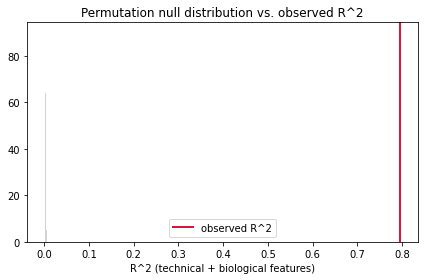

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(null_r2, bins=40, color="lightgray")
ax.axvline(r2_full, color="crimson", linewidth=2, label="observed R^2")
ax.set_xlabel("R^2 (technical + biological features)")
ax.set_title("Permutation null distribution vs. observed R^2")
ax.legend()
plt.tight_layout()
plt.show()

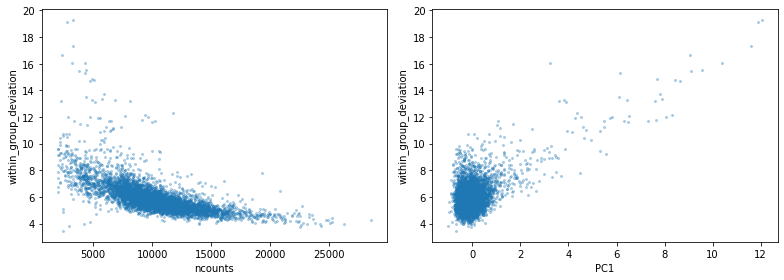

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(adata.obs["ncounts"], adata.obs["within_group_deviation"], s=4, alpha=0.3)
axes[0].set_xlabel("ncounts")
axes[0].set_ylabel("within_group_deviation")

axes[1].scatter(biological_features["PC1"], adata.obs["within_group_deviation"], s=4, alpha=0.3)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("within_group_deviation")

plt.tight_layout()
plt.show()

In [13]:
low_count_cutoff = np.percentile(adata.obs["ncounts"], 2)
keep = adata.obs["ncounts"].values > low_count_cutoff
print("cells excluded as extreme low-count outliers:", (~keep).sum(), "of", len(keep))

_, r2_technical_trimmed = fit_r2(X_technical[keep], target[keep])
_, r2_full_trimmed = fit_r2(X_full[keep], target[keep])

print("R^2, technical only, after excluding extreme low-count cells:", r2_technical_trimmed)
print("R^2, technical + biological, after excluding extreme low-count cells:", r2_full_trimmed)

cells excluded as extreme low-count outliers: 116 of 5752
R^2, technical only, after excluding extreme low-count cells: 0.4494101825258826
R^2, technical + biological, after excluding extreme low-count cells: 0.7755093368149422


In [14]:
output_path = "F:/scRNA/response_heterogeneity_summary.csv"
adata.obs[["perturbation", "within_group_deviation", "ncounts", "ngenes", "percent_ribo"]].to_csv(
    "F:/scRNA/per_cell_baseline_and_deviation.csv"
)
print("saved to F:/scRNA/per_cell_baseline_and_deviation.csv")

saved to F:/scRNA/per_cell_baseline_and_deviation.csv
